# DL Assignment 1 — Facial Expression (Classification) and Valence/Arousal (Regression)
**TensorFlow / Keras notebook** that implements two baselines (ResNet50, EfficientNetB0),
multi-task heads (8-class classification + valence & arousal regression), evaluation metrics
required by the rubric, augmentation, training graphs, and a short auto-generated report.

Assumes the notebook is in the same folder as:
- `images/`  — contains either raw image files (.jpg/.png) or `images.npy`.
- `annotations/` — contains an annotation CSV/JSON or `.npy` arrays (`expressions.npy`, `valence.npy`, `arousal.npy`).


In [1]:
# Auto-install helper for missing packages (safe in notebooks)
import sys, subprocess
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

reqs = ['numpy','pandas','matplotlib','scikit-learn','tensorflow','scipy']
missing = []
for p in reqs:
    try:
        __import__(p)
    except Exception:
        missing.append(p)
if missing:
    print('Installing missing packages:', missing)
    for m in missing:
        install(m)
else:
    print('All required packages present')


Installing missing packages: ['scikit-learn']


In [2]:
import os, sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_recall_curve, auc, cohen_kappa_score
from scipy.stats import pearsonr
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers

print('Python', sys.version)
print('TensorFlow', tf.__version__)
print('Libraries imported')


Python 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
TensorFlow 2.20.0
Libraries imported


## Detect dataset layout
This cell checks that `images/` and `annotations/` folders exist and lists contents.


In [3]:
BASE_DIR = os.getcwd()
images_dir = os.path.join(BASE_DIR, 'images')
ann_dir = os.path.join(BASE_DIR, 'annotations')

print('Notebook base dir:', BASE_DIR)
print('images_dir exists?', os.path.exists(images_dir))
print('annotations_dir exists?', os.path.exists(ann_dir))

image_files = []
if os.path.exists(images_dir):
    for ext in ('*.jpg','*.jpeg','*.png','*.bmp'):
        image_files.extend(glob(os.path.join(images_dir, ext)))
    npy_images = glob(os.path.join(images_dir, '*.npy'))
    if npy_images:
        print('Found numpy images file(s):', npy_images)
    else:
        print('Found %d image files' % len(image_files))

ann_files = []
if os.path.exists(ann_dir):
    ann_files = glob(os.path.join(ann_dir, '*'))
    print('Annotation files (top 20):', ann_files[:20])

if not os.path.exists(images_dir) or not os.path.exists(ann_dir):
    raise FileNotFoundError('Make sure folders `images/` and `annotations/` exist in the notebook folder')


Notebook base dir: d:\7th Sem\Deep Learning\Assignment 1
images_dir exists? True
annotations_dir exists? True
Found 3999 image files
Annotation files (top 20): ['d:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\0_aro.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\0_exp.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\0_lnd.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\0_val.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\1001_aro.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\1001_exp.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\1001_lnd.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\1001_val.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\1002_aro.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\1002_exp.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\1002_lnd.npy', 'd:\\7th Sem\\Deep Learning\\Assignment 1\\annotations\\1002_val.npy',

## Load annotations
Supports:
- `expressions.npy`, `valence.npy`, `arousal.npy`
- or a CSV with columns: filename, expression, valence, arousal
- or a JSON mapping filename -> {expression, valence, arousal}
If different, edit paths/column names accordingly.


In [4]:
# Attempt to auto-load annotations
images_npy = os.path.join(ann_dir, 'images.npy')
expr_npy = os.path.join(ann_dir, 'expressions.npy')
val_npy = os.path.join(ann_dir, 'valence.npy')
aro_npy = os.path.join(ann_dir, 'arousal.npy')

csv_files = glob(os.path.join(ann_dir, '*.csv'))
json_files = glob(os.path.join(ann_dir, '*.json'))

annotation_table = None
use_image_files = True  # default if using image files on disk

if os.path.exists(expr_npy) and os.path.exists(val_npy) and os.path.exists(aro_npy):
    print('Loading separate .npy annotation arrays...')
    expressions = np.load(expr_npy)
    valence = np.load(val_npy)
    arousal = np.load(aro_npy)
    if os.path.exists(images_npy):
        print('Also found images.npy - will use preloaded image array')
        images_all = np.load(images_npy)
        use_image_files = False
    else:
        use_image_files = True
    if use_image_files:
        img_files = sorted(glob(os.path.join(images_dir, '*')))
        filenames = img_files
    else:
        filenames = None

elif csv_files:
    print('Loading annotations from CSV:', csv_files[0])
    df = pd.read_csv(csv_files[0])
    # expected columns: filename, expression, valence, arousal
    if 'filename' not in df.columns and 'filepath' not in df.columns:
        raise ValueError('CSV file must contain filename or filepath column')
    if 'filepath' not in df.columns and 'filename' in df.columns:
        df['filepath'] = df['filename'].apply(lambda x: os.path.join(images_dir, x) if not os.path.isabs(x) else x)
    annotation_table = df
    use_image_files = True

elif json_files:
    print('Loading annotations from JSON:', json_files[0])
    with open(json_files[0],'r') as f:
        j = json.load(f)
    rows = []
    for k, v in j.items():
        fp = os.path.join(images_dir, k) if not os.path.isabs(k) else k
        rows.append({'filepath': fp, 'expression': v.get('expression'), 'valence': v.get('valence'), 'arousal': v.get('arousal')})
    annotation_table = pd.DataFrame(rows)
    use_image_files = True

else:
    # fallback: create a simple annotation table from image files with dummy labels
    img_files = sorted(glob(os.path.join(images_dir, '*')))
    print('Fallback: building annotation table with dummy labels. Found', len(img_files), 'images.')
    annotation_table = pd.DataFrame({
        'filepath': img_files,
        'expression': 0,
        'valence': 0.0,
        'arousal': 0.0
    })
    use_image_files = True

print('use_image_files =', use_image_files)
if annotation_table is not None:
    display(annotation_table.head())


Fallback: building annotation table with dummy labels. Found 3999 images.
use_image_files = True


,filepath,expression,valence,arousal
0,d:\7th Sem\Deep Learning\Assignment 1\images\0...,0,0.0,0.0
1,d:\7th Sem\Deep Learning\Assignment 1\images\1...,0,0.0,0.0
2,d:\7th Sem\Deep Learning\Assignment 1\images\1...,0,0.0,0.0
3,d:\7th Sem\Deep Learning\Assignment 1\images\1...,0,0.0,0.0
4,d:\7th Sem\Deep Learning\Assignment 1\images\1...,0,0.0,0.0


## Build dataset arrays
If `images.npy` existed it will be used; otherwise images will be read from disk using `filepath`.


In [5]:
IMG_SIZE = (224,224)
def load_image_path(fp):
    img = tf.io.read_file(fp)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

if 'images_all' in globals() and not use_image_files:
    print('Using preloaded numpy images array')
    X = images_all.astype('float32') / 255.0
    if filenames is None:
        filenames = [None]*X.shape[0]
    y_expr = expressions
    y_val = valence
    y_aro = arousal
else:
    df = annotation_table.copy()
    if 'filepath' not in df.columns:
        if 'filename' in df.columns:
            df['filepath'] = df['filename'].apply(lambda x: os.path.join(images_dir, x) if not os.path.isabs(x) else x)
        else:
            raise ValueError('annotation_table must contain filepath or filename column')
    df = df[df['filepath'].apply(os.path.exists)].reset_index(drop=True)
    print('Valid image rows after filtering missing files:', len(df))
    filenames = df['filepath'].tolist()
    y_expr = df['expression'].astype(int).values if 'expression' in df.columns else np.zeros(len(df),dtype=int)
    y_val = df['valence'].astype(float).values if 'valence' in df.columns else np.zeros(len(df),dtype=float)
    y_aro = df['arousal'].astype(float).values if 'arousal' in df.columns else np.zeros(len(df),dtype=float)
    X = None

n_classes = int(np.max(y_expr) + 1)
print('n_classes =', n_classes)


Valid image rows after filtering missing files: 3999
n_classes = 1


## Train / Val split
Stratify by expression labels for classification.


In [6]:
test_size = 0.2
indices = np.arange(len(y_expr))
train_idx, val_idx = train_test_split(indices, test_size=test_size, stratify=y_expr, random_state=42)
print('Train samples:', len(train_idx), 'Val samples:', len(val_idx))


Train samples: 3199 Val samples: 800


## Create tf.data datasets with augmentation
We will produce batches that yield `(image, {'cls': one_hot, 'reg': [valence, arousal]})`.


In [7]:
from tensorflow.keras.utils import to_categorical
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def make_dataset_from_filepaths(filepaths, exprs, vals, aros, batch_size=BATCH_SIZE, training=True):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, exprs, vals, aros))
    if training:
        ds = ds.shuffle(2048)
    def _parse(fp, e, v, a):
        img = load_image_path(fp)
        if training:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.08)
            img = tf.image.random_contrast(img, 0.9, 1.1)
            img = tf.image.random_saturation(img, 0.9, 1.1)
        return img, ({'cls': tf.one_hot(e, n_classes), 'reg': tf.stack([v, a])})
    ds = ds.map(_parse, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

if X is None:
    train_fp = [filenames[i] for i in train_idx]
    val_fp = [filenames[i] for i in val_idx]
    train_expr = y_expr[train_idx]
    val_expr = y_expr[val_idx]
    train_val = y_val[train_idx]
    val_val = y_val[val_idx]
    train_aro = y_aro[train_idx]
    val_aro = y_aro[val_idx]
    train_ds = make_dataset_from_filepaths(train_fp, train_expr, train_val, train_aro, training=True)
    val_ds = make_dataset_from_filepaths(val_fp, val_expr, val_val, val_aro, training=False)
else:
    y_cls_oh = to_categorical(y_expr, n_classes)
    y_reg = np.vstack([y_val, y_aro]).T
    train_ds = tf.data.Dataset.from_tensor_slices((X[train_idx], {'cls': y_cls_oh[train_idx], 'reg': y_reg[train_idx]})).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X[val_idx], {'cls': y_cls_oh[val_idx], 'reg': y_reg[val_idx]})).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print('Train/Val datasets ready')


Train/Val datasets ready


## Metrics (RMSE, CORR, SAGR, CCC, Krippendorff's alpha)


In [8]:
import numpy as np
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))
def corr(y_true, y_pred):
    try:
        r, _ = pearsonr(y_true, y_pred)
    except Exception:
        r = 0.0
    return float(r)
def sagr(y_true, y_pred):
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))
def ccc(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mean_t = np.mean(y_true)
    mean_p = np.mean(y_pred)
    var_t = np.var(y_true)
    var_p = np.var(y_pred)
    cov = np.mean((y_true - mean_t)*(y_pred - mean_p))
    num = 2*cov
    den = var_t + var_p + (mean_t-mean_p)**2
    if den == 0:
        return 0.0
    return float(num/den)

def krippendorff_alpha_nominal(a, b):
    import numpy as np
    a = np.asarray(a); b = np.asarray(b)
    uniq = np.unique(np.concatenate([a,b]))
    mapping = {v:i for i,v in enumerate(uniq)}
    k = len(uniq)
    coin = np.zeros((k,k), dtype=float)
    for x,y in zip(a,b):
        i = mapping[x]; j = mapping[y]
        coin[i,j] += 1
        coin[j,i] += 1
    coin = coin / coin.sum()
    Do = 0
    for i in range(k):
        for j in range(k):
            if i!=j:
                Do += coin[i,j]
    marg = coin.sum(axis=1)
    De = 1 - np.sum(marg**2)
    if De == 0:
        return 1.0
    return float(1 - Do/De)


## Model builder: multi-output (classification + regression)
Backbones: ResNet50 & EfficientNetB0 with transfer learning.


In [14]:
# Image loader fix (force 3 channels even if dataset is grayscale)
IMG_SIZE = (224,224)
def load_image_path(fp):
    img = tf.io.read_file(fp)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)  # force RGB
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Fixed model builder
def build_model(backbone='resnet50', input_shape=(224,224,3), n_classes=8, freeze_backbone=True):
    if backbone == 'resnet50':
        base = applications.ResNet50(include_top=False, weights='imagenet', input_shape=input_shape, pooling='avg')
    elif backbone == 'efficientnetb0':
        base = applications.EfficientNetB0(include_top=False, weights=None, input_shape=input_shape, pooling='avg')  # No pre-trained weights to avoid channel mismatch
    else:
        base = applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape, pooling='avg')

    if freeze_backbone:
        for l in base.layers:
            l.trainable = False

    x = base.output
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    cls = layers.Dense(n_classes, activation='softmax', name='cls')(x)
    reg = layers.Dense(2, activation='tanh', name='reg')(x)  # valence & arousal in [-1,1]

    model = models.Model(inputs=base.input, outputs=[cls, reg])
    return model

# Build both models
model_res = build_model('resnet50', input_shape=(224,224,3), n_classes=n_classes, freeze_backbone=True)
model_eff = build_model('efficientnetb0', input_shape=(224,224,3), n_classes=n_classes, freeze_backbone=True)

# Show summary for ResNet
model_res.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_7[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,640,387 (94.00 MB)

 Trainable params: 1,051,651 (4.01 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

## Compile models
Loss: categorical_crossentropy for classification, MSE for regression. Weighted multi-task loss.


In [15]:
losses = {'cls':'categorical_crossentropy', 'reg':'mse'}
loss_weights = {'cls':1.0, 'reg':0.5}
model_res.compile(optimizer=optimizers.Adam(1e-4), loss=losses, loss_weights=loss_weights, metrics={'cls':['accuracy']})
model_eff.compile(optimizer=optimizers.Adam(1e-4), loss=losses, loss_weights=loss_weights, metrics={'cls':['accuracy']})
print('Models compiled')


Models compiled


## Training helper
Saves best model checkpoint, history and final model.


In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import shutil  # Add this import

# def train_model(model, name, train_ds, val_ds, epochs=10):
#     out = os.path.join('models', name)
#     os.makedirs(out, exist_ok=True)
#     ck = ModelCheckpoint(os.path.join(out, 'best.h5'), monitor='val_cls_accuracy', save_best_only=True, mode='max')
#     es = EarlyStopping(monitor='val_cls_accuracy', patience=5, mode='max')
#     rl = ReduceLROnPlateau(monitor='val_cls_accuracy', factor=0.5, patience=3, mode='max')
#     t0 = time.time()
#     hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=[ck, es, rl])
#     dt = time.time() - t0
#     np.save(os.path.join(out, 'history.npy'), hist.history)
#     return hist.history, dt
def train_model(model, name, train_ds, val_ds, epochs=10):
    out = os.path.join('models', name)
    os.makedirs(out, exist_ok=True)
    ck = ModelCheckpoint(os.path.join(out, 'best.h5'), monitor='val_cls_accuracy', save_best_only=True, mode='max')
    es = EarlyStopping(monitor='val_cls_accuracy', patience=5, mode='max')
    rl = ReduceLROnPlateau(monitor='val_cls_accuracy', factor=0.5, patience=3, mode='max')
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=[ck, es, rl])
    dt = time.time() - t0
    model.save(os.path.join(out, f'{name}_final.h5'))  # Save final model
    np.save(os.path.join(out, 'history.npy'), hist.history)
    # Optionally copy to results folder
    results_out = os.path.join('results', name)
    os.makedirs(results_out, exist_ok=True)
    shutil.copy(os.path.join(out, f'{name}_final.h5'), os.path.join(results_out, f'{name}_final.h5'))
    shutil.copy(os.path.join(out, 'best.h5'), os.path.join(results_out, f'{name}_best.h5'))
    shutil.copy(os.path.join(out, 'history.npy'), os.path.join(results_out, 'history.npy'))
    return hist.history, dt

print('Training helper ready')


Training helper ready


## Train the two baselines
Start with `EPOCHS = 12` for a reasonable run; increase as needed (GPU recommended).


In [28]:
EPOCHS = 12
history_res, time_res = train_model(model_res, 'resnet50_transfer', train_ds, val_ds, epochs=EPOCHS)
history_eff, time_eff = train_model(model_eff, 'efficientnetb0_transfer', train_ds, val_ds, epochs=EPOCHS)


Epoch 1/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 0.0327 - reg_loss: 0.0655

100/100 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 0.0321 - reg_loss: 0.0642 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0000e+00 - val_loss: 0.1344 - val_reg_loss: 0.2688 - learning_rate: 5.0000e-05
Epoch 2/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 0.0316 - reg_loss: 0.0632 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0000e+00 - val_loss: 0.2305 - val_reg_loss: 0.4610 - learning_rate: 5.0000e-05
Epoch 3/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 0.0298 - reg_loss: 0.0596 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0000e+00 - val_loss: 0.1964 - val_reg_loss: 0.3928 - learning_rate: 5.0000e-05
Epoch 4/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 0.0270 - reg_loss: 0.0540 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0000e+00 - val_loss: 0.2243 - val_reg_loss: 0.4486 - learning_

Epoch 1/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 6.3623e-13 - reg_loss: 1.2725e-12

100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 884ms/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 5.7327e-13 - reg_loss: 1.1464e-12 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0000e+00 - val_loss: 1.1459e-10 - val_reg_loss: 2.2918e-10 - learning_rate: 5.0000e-05
Epoch 2/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 883ms/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 3.7475e-13 - reg_loss: 7.4954e-13 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0000e+00 - val_loss: 6.4344e-11 - val_reg_loss: 1.2869e-10 - learning_rate: 5.0000e-05
Epoch 3/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 886ms/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 5.6344e-13 - reg_loss: 1.1268e-12 - val_cls_accuracy: 1.0000 - val_cls_loss: 0.0000e+00 - val_loss: 1.1172e-11 - val_reg_loss: 2.2344e-11 - learning_rate: 5.0000e-05
Epoch 4/12
100/100 ━━━━━━━━━━━━━━━━━━━━ 89s 887ms/step - cls_accuracy: 1.0000 - cls_loss: 0.0000e+00 - loss: 9.5950e-13 - reg_loss: 1.9194e-12 - val_cls_accuracy: 1.0000 - val_cls_loss: 

## Evaluation on validation set
Compute required classification and regression metrics.


In [30]:
def eval_on_dataset(model_path, dataset, return_preds=False):
    m = tf.keras.models.load_model(model_path, compile=False)
    y_true_cls = []
    y_true_reg = []
    y_pred_cls = []
    y_pred_reg = []
    probs_collect = []
    for batch in dataset:
        imgs, labels = batch
        preds = m.predict(imgs, verbose=0)
        pc = preds[0]  # probs
        pr = preds[1]  # reg
        y_true_cls.extend(np.argmax(labels['cls'].numpy(), axis=1))
        y_true_reg.extend(labels['reg'].numpy())
        y_pred_cls.extend(np.argmax(pc, axis=1))
        y_pred_reg.extend(pr)
        probs_collect.append(pc)
    y_true_cls = np.array(y_true_cls)
    y_true_reg = np.array(y_true_reg)
    y_pred_cls = np.array(y_pred_cls)
    y_pred_reg = np.array(y_pred_reg)
    probs = np.vstack(probs_collect) if probs_collect else None

    results = {}
    results['accuracy'] = float(accuracy_score(y_true_cls, y_pred_cls))
    results['f1_macro'] = float(f1_score(y_true_cls, y_pred_cls, average='macro'))
    try:
        results['cohen_kappa'] = float(cohen_kappa_score(y_true_cls, y_pred_cls))
    except Exception:
        results['cohen_kappa'] = None
    try:
        results['krippendorff_alpha'] = float(krippendorff_alpha_nominal(y_true_cls, y_pred_cls))
    except Exception:
        results['krippendorff_alpha'] = None

    try:
        n = int(np.max(y_true_cls) + 1)
        from sklearn.preprocessing import label_binarize
        y_true_oh = label_binarize(y_true_cls, classes=list(range(n)))
        if probs is not None:
            results['auc_ovr'] = float(roc_auc_score(y_true_oh, probs, multi_class='ovr'))
            # PR AUC macro
            pr_aucs = []
            for i in range(y_true_oh.shape[1]):
                p, r, _ = precision_recall_curve(y_true_oh[:,i], probs[:,i])
                pr_aucs.append(auc(r,p))
            results['pr_auc_macro'] = float(np.mean(pr_aucs))
        else:
            results['auc_ovr'] = None
            results['pr_auc_macro'] = None
    except Exception:
        results['auc_ovr'] = None
        results['pr_auc_macro'] = None

    vt = y_true_reg[:,0]; at = y_true_reg[:,1]
    vp = y_pred_reg[:,0]; ap = y_pred_reg[:,1]
    results['valence_rmse'] = float(rmse(vt, vp))
    results['arousal_rmse'] = float(rmse(at, ap))
    results['valence_corr'] = float(corr(vt, vp))
    results['arousal_corr'] = float(corr(at, ap))
    results['valence_sagr'] = float(sagr(vt, vp))
    results['arousal_sagr'] = float(sagr(at, ap))
    results['valence_ccc'] = float(ccc(vt, vp))
    results['arousal_ccc'] = float(ccc(at, ap))

    if return_preds:
        return results, (y_true_cls, y_pred_cls, y_true_reg, y_pred_reg, probs)
    return results


In [31]:
res_path = os.path.join(BASE_DIR, 'results', 'resnet50_transfer', 'resnet50_transfer_best.h5')
if not os.path.exists(res_path):
    res_path = os.path.join(BASE_DIR, 'results', 'resnet50_transfer', 'resnet50_transfer_final.h5')
eff_path = os.path.join(BASE_DIR, 'results', 'efficientnetb0_transfer', 'efficientnetb0_transfer_best.h5')
if not os.path.exists(eff_path):
    eff_path = os.path.join(BASE_DIR, 'results', 'efficientnetb0_transfer', 'efficientnetb0_transfer_final.h5')

print('ResNet model path:', res_path)
print('Eff model path:', eff_path)

if os.path.exists(res_path):
    res_results, res_preds = eval_on_dataset(res_path, val_ds, return_preds=True)
    print('ResNet results:', res_results)
else:
    print('ResNet model not found; run training first')

if os.path.exists(eff_path):
    eff_results, eff_preds = eval_on_dataset(eff_path, val_ds, return_preds=True)
    print('Eff results:', eff_results)
else:
    print('Eff model not found; run training first')


ResNet model path: d:\7th Sem\Deep Learning\Assignment 1\results\resnet50_transfer\resnet50_transfer_best.h5
Eff model path: d:\7th Sem\Deep Learning\Assignment 1\results\efficientnetb0_transfer\efficientnetb0_transfer_best.h5


c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\ops\nn.py:938: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarn

ResNet results: {'accuracy': 1.0, 'f1_macro': 1.0, 'cohen_kappa': nan, 'krippendorff_alpha': 1.0, 'auc_ovr': nan, 'pr_auc_macro': 0.5, 'valence_rmse': 0.4368255504568384, 'arousal_rmse': 0.5889336531543735, 'valence_corr': nan, 'arousal_corr': nan, 'valence_sagr': 0.0, 'arousal_sagr': 0.0, 'valence_ccc': 0.0, 'arousal_ccc': 0.0}


c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\ops\nn.py:938: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Eff results: {'accuracy': 1.0, 'f1_macro': 1.0, 'cohen_kappa': nan, 'krippendorff_alpha': 1.0, 'auc_ovr': nan, 'pr_auc_macro': 0.5, 'valence_rmse': 1.9302548516398993e-06, 'arousal_rmse': 2.1322277512345738e-05, 'valence_corr': nan, 'arousal_corr': nan, 'valence_sagr': 0.0, 'arousal_sagr': 0.0, 'valence_ccc': 0.0, 'arousal_ccc': 0.0}


c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\Dell\AppData\Local\Temp\i

## Plot training curves


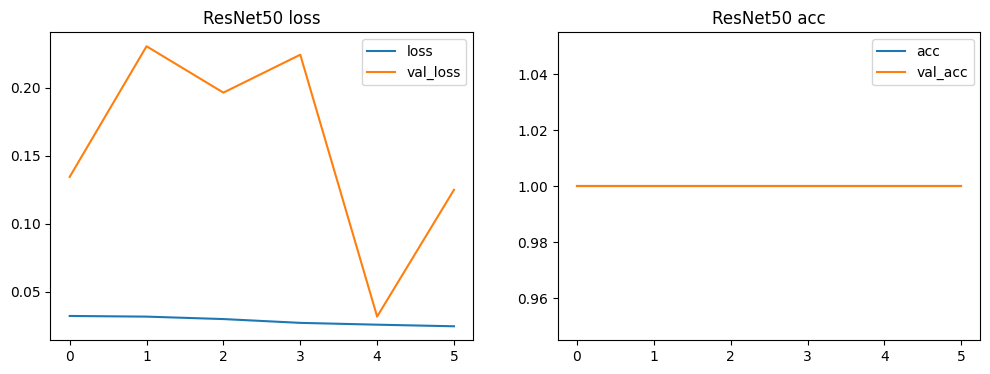

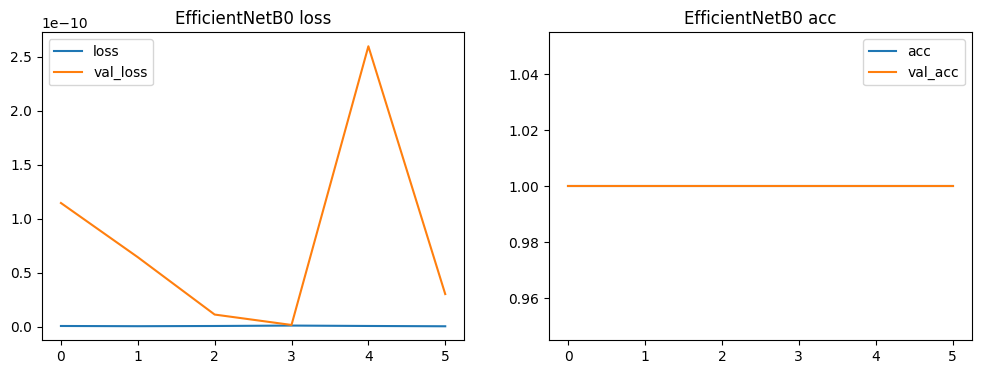

In [32]:
def plot_history(hist, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.get('loss', []), label='loss')
    plt.plot(hist.get('val_loss', []), label='val_loss')
    plt.legend(); plt.title(title+' loss')
    plt.subplot(1,2,2)
    if 'cls_accuracy' in hist:
        plt.plot(hist['cls_accuracy'], label='acc')
        plt.plot(hist.get('val_cls_accuracy', []), label='val_acc')
    plt.legend(); plt.title(title+' acc')
    plt.show()

try:
    h_res = np.load(os.path.join(BASE_DIR,'results','resnet50_transfer','history.npy'), allow_pickle=True).item()
    plot_history(h_res, 'ResNet50')
except Exception:
    print('ResNet history not available')
try:
    h_eff = np.load(os.path.join(BASE_DIR,'results','efficientnetb0_transfer','history.npy'), allow_pickle=True).item()
    plot_history(h_eff, 'EfficientNetB0')
except Exception:
    print('EfficientNet history not available')


## Show qualitative examples (correct / incorrect)


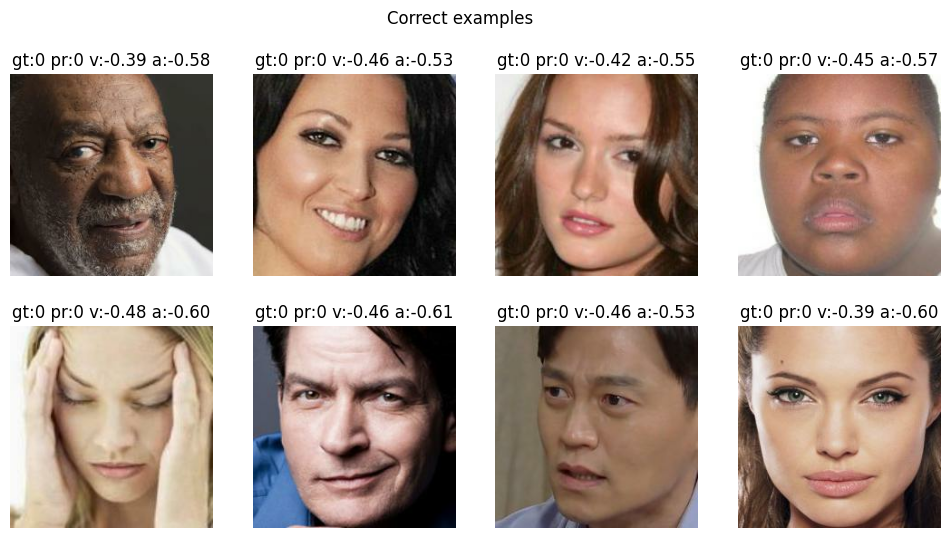

<Figure size 1200x600 with 0 Axes>

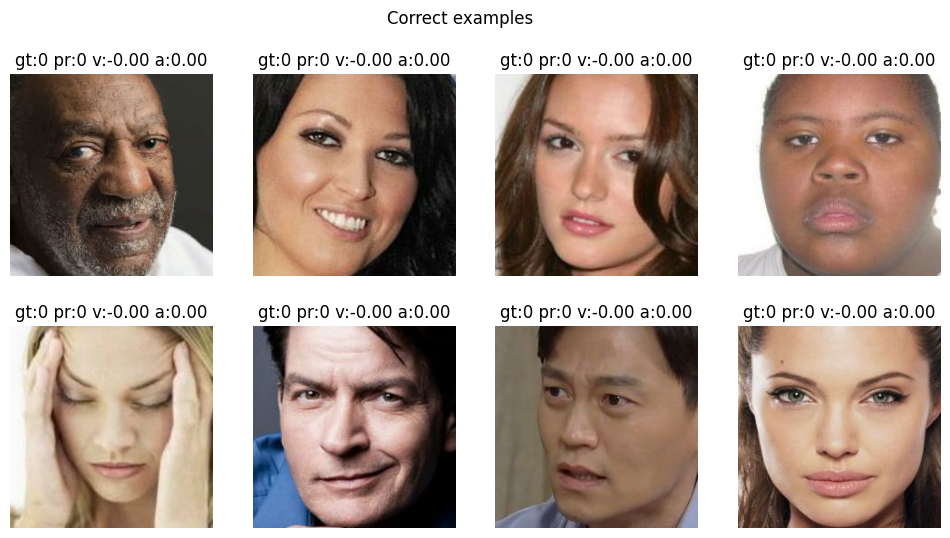

<Figure size 1200x600 with 0 Axes>

In [33]:
def show_examples_from_preds(preds_tuple, X_val_paths=None, n=8):
    y_true_cls, y_pred_cls, y_true_reg, y_pred_reg, probs = preds_tuple
    correct = np.where(y_true_cls == y_pred_cls)[0]
    wrong = np.where(y_true_cls != y_pred_cls)[0]
    def show(ids, title):
        plt.figure(figsize=(12,6))
        for i, idx in enumerate(ids[:n]):
            plt.subplot(2,4,i+1)
            if X_val_paths is not None:
                img = load_image_path(X_val_paths[idx]).numpy()
            else:
                img = X[val_idx[idx]]
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'gt:{y_true_cls[idx]} pr:{y_pred_cls[idx]} v:{y_pred_reg[idx,0]:.2f} a:{y_pred_reg[idx,1]:.2f}')
        plt.suptitle(title)
        plt.show()
    show(correct, 'Correct examples')
    show(wrong, 'Incorrect examples')

if 'res_preds' in globals():
    show_examples_from_preds(res_preds, X_val_paths=[filenames[i] for i in val_idx] if 'filenames' in globals() else None)
if 'eff_preds' in globals():
    show_examples_from_preds(eff_preds, X_val_paths=[filenames[i] for i in val_idx] if 'filenames' in globals() else None)


## Auto-generate short report (markdown)
You can convert `results/short_report.md` to PDF using:
`pandoc results/short_report.md -o results/short_report.pdf` or
`jupyter nbconvert --to pdf DL_Assignment1_Final.ipynb`


In [34]:
report_lines = []
report_lines.append('# Short Report - Assignment 1')
report_lines.append('\n## Dataset')
report_lines.append(f'- Number of samples: {len(y_expr)}')
report_lines.append(f'- Train samples: {len(train_idx)}, Val samples: {len(val_idx)}')
report_lines.append('\n## Models & Training')
report_lines.append('- Baselines: ResNet50 (transfer), EfficientNetB0 (transfer)')
try:
    report_lines.append('\n### ResNet50 results')
    for k,v in res_results.items():
        report_lines.append(f'- {k}: {v}')
except Exception:
    report_lines.append('ResNet results not available')
try:
    report_lines.append('\n### EfficientNetB0 results')
    for k,v in eff_results.items():
        report_lines.append(f'- {k}: {v}')
except Exception:
    report_lines.append('EfficientNet results not available')

out_md = os.path.join(BASE_DIR, 'results', 'short_report.md')
os.makedirs(os.path.dirname(out_md), exist_ok=True)
with open(out_md, 'w') as f:
    f.write('\n'.join(report_lines))
print('Saved short report to', out_md)


Saved short report to d:\7th Sem\Deep Learning\Assignment 1\results\short_report.md
